# 天气数据分析

In [2]:
import pandas as pd
from pandas.core.interchange.from_dataframe import primitive_column_to_ndarray

df = pd.read_csv("weather.csv")
print(df)

            date  precipitation  temp_max  temp_min  wind  weather
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle
1     2012-01-02           10.9      10.6       2.8   4.5     rain
2     2012-01-03            0.8      11.7       7.2   2.3     rain
3     2012-01-04           20.3      12.2       5.6   4.7     rain
4     2012-01-05            1.3       8.9       2.8   6.1     rain
...          ...            ...       ...       ...   ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain
1457  2015-12-28            1.5       5.0       1.7   1.3     rain
1458  2015-12-29            0.0       7.2       0.6   2.6      fog
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun

[1461 rows x 6 columns]


In [3]:
# 按照月份分组  并且统计最高温度 和 最低温度的平均值

df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)
print(df)

            date  precipitation  temp_max  temp_min  wind  weather    month
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012-01
1     2012-01-02           10.9      10.6       2.8   4.5     rain  2012-01
2     2012-01-03            0.8      11.7       7.2   2.3     rain  2012-01
3     2012-01-04           20.3      12.2       5.6   4.7     rain  2012-01
4     2012-01-05            1.3       8.9       2.8   6.1     rain  2012-01
...          ...            ...       ...       ...   ...      ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain  2015-12
1457  2015-12-28            1.5       5.0       1.7   1.3     rain  2015-12
1458  2015-12-29            0.0       7.2       0.6   2.6      fog  2015-12
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun  2015-12
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun  2015-12

[1461 rows x 7 columns]


In [4]:
# 分组操作 groupby  分组以后获取到的是一个分组对象
group_obj = df.groupby("month")
print(group_obj)

In [5]:
# 指定要聚合的列
month_temp = group_obj[["temp_max","temp_min"]]
print(month_temp)

In [6]:
# 最终 执行聚合操作
month_temp_mean = month_temp.mean()
print(month_temp_mean)

          temp_max   temp_min
month                        
2012-01   7.054839   1.541935
2012-02   9.275862   3.203448
2012-03   9.554839   2.838710
2012-04  14.873333   5.993333
2012-05  17.661290   8.190323
2012-06  18.693333  10.480000
2012-07  22.906452  12.932258
2012-08  25.858065  14.009677
2012-09  22.880000  11.243333
2012-10  15.829032   8.380645
2012-11  11.326667   5.226667
2012-12   7.235484   3.293548
2013-01   6.106452   0.796774
2013-02   9.467857   4.325000
2013-03  12.709677   4.977419
2013-04  14.243333   6.696667
2013-05  19.625806   9.922581
2013-06  23.253333  13.163333
2013-07  26.093548  13.932258
2013-08  26.119355  15.480645
2013-09  21.360000  13.590000
2013-10  14.229032   7.638710
2013-11  12.053333   5.590000
2013-12   7.022581   1.570968
2014-01   9.600000   4.096774
2014-02   8.200000   2.635714
2014-03  12.906452   5.425806
2014-04  15.460000   6.730000
2014-05  19.870968  10.216129
2014-06  21.590000  11.756667
2014-07  26.900000  14.425806
2014-08  2

In [7]:
# 合并为一条语句的写法
month_df = df.groupby("month")[["temp_max","temp_min"]].mean()
print(month_df)

          temp_max   temp_min
month                        
2012-01   7.054839   1.541935
2012-02   9.275862   3.203448
2012-03   9.554839   2.838710
2012-04  14.873333   5.993333
2012-05  17.661290   8.190323
2012-06  18.693333  10.480000
2012-07  22.906452  12.932258
2012-08  25.858065  14.009677
2012-09  22.880000  11.243333
2012-10  15.829032   8.380645
2012-11  11.326667   5.226667
2012-12   7.235484   3.293548
2013-01   6.106452   0.796774
2013-02   9.467857   4.325000
2013-03  12.709677   4.977419
2013-04  14.243333   6.696667
2013-05  19.625806   9.922581
2013-06  23.253333  13.163333
2013-07  26.093548  13.932258
2013-08  26.119355  15.480645
2013-09  21.360000  13.590000
2013-10  14.229032   7.638710
2013-11  12.053333   5.590000
2013-12   7.022581   1.570968
2014-01   9.600000   4.096774
2014-02   8.200000   2.635714
2014-03  12.906452   5.425806
2014-04  15.460000   6.730000
2014-05  19.870968  10.216129
2014-06  21.590000  11.756667
2014-07  26.900000  14.425806
2014-08  2

In [8]:
# 按照月份分组 统计当前月出现了几种不同的天气

w_count_df = df.groupby("month")["weather"].nunique()
print(w_count_df)


month
2012-01    4
2012-02    4
2012-03    4
2012-04    4
2012-05    3
2012-06    3
2012-07    4
2012-08    3
2012-09    4
2012-10    3
2012-11    4
2012-12    4
2013-01    4
2013-02    3
2013-03    5
2013-04    4
2013-05    3
2013-06    2
2013-07    2
2013-08    3
2013-09    3
2013-10    3
2013-11    4
2013-12    3
2014-01    3
2014-02    3
2014-03    3
2014-04    2
2014-05    2
2014-06    2
2014-07    3
2014-08    3
2014-09    3
2014-10    3
2014-11    4
2014-12    3
2015-01    3
2015-02    3
2015-03    3
2015-04    3
2015-05    3
2015-06    4
2015-07    4
2015-08    4
2015-09    3
2015-10    4
2015-11    3
2015-12    3
Name: weather, dtype: int64


Axes(0.125,0.11;0.775x0.77)


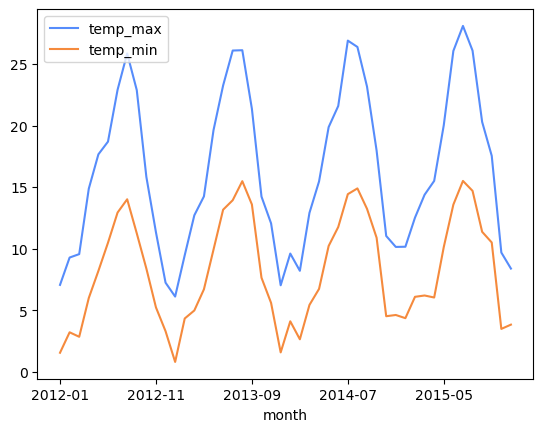

In [9]:
# 按照月份分组 统计最高温度 最低温度 平均值
# 以折线图的方式进行展示
month_df = df.groupby("month")[["temp_max","temp_min"]].mean().plot()
print(month_df)

In [10]:
# 生成当前DataFrame的常用统计数据
print(df.describe())

       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.029432    16.439083     8.234771     3.241136
std         6.680194     7.349758     5.023004     1.437825
min         0.000000    -1.600000    -7.100000     0.400000
25%         0.000000    10.600000     4.400000     2.200000
50%         0.000000    15.600000     8.300000     3.000000
75%         2.800000    22.200000    12.200000     4.000000
max        55.900000    35.600000    18.300000     9.500000


In [11]:
# 行列转置
print(df.describe().T)

                count       mean       std  min   25%   50%   75%   max
precipitation  1461.0   3.029432  6.680194  0.0   0.0   0.0   2.8  55.9
temp_max       1461.0  16.439083  7.349758 -1.6  10.6  15.6  22.2  35.6
temp_min       1461.0   8.234771  5.023004 -7.1   4.4   8.3  12.2  18.3
wind           1461.0   3.241136  1.437825  0.4   2.2   3.0   4.0   9.5


In [12]:
# 获取最高气温前30条数据
print(df.nlargest(30, "temp_max"))

            date  precipitation  temp_max  temp_min  wind  weather    month
953   2014-08-11            0.5      35.6      17.8   2.6     rain  2014-08
1295  2015-07-19            0.0      35.0      17.2   3.3      sun  2015-07
228   2012-08-16            0.0      34.4      18.3   2.8      sun  2012-08
912   2014-07-01            0.0      34.4      15.6   3.5      sun  2014-07
1306  2015-07-30            0.0      34.4      17.2   3.5      sun  2015-07
1307  2015-07-31            0.0      34.4      17.8   2.6      sun  2015-07
216   2012-08-04            0.0      33.9      16.7   3.7      sun  2012-08
217   2012-08-05            0.0      33.9      17.8   1.9      sun  2012-08
546   2013-06-30            0.0      33.9      17.2   2.5      sun  2013-06
619   2013-09-11            0.0      33.9      16.1   2.4      sun  2013-09
1278  2015-07-02            0.0      33.9      17.8   3.4      sun  2015-07
1273  2015-06-27            0.0      33.3      17.2   3.9      sun  2015-06
1279  2015-0

In [13]:
# 先获取最高温度的前30条信息 再从这些信息找到最低温度的前5条信息
print(df.nlargest(30, "temp_max").nsmallest(5, "temp_min"))

            date  precipitation  temp_max  temp_min  wind weather    month
250   2012-09-07            0.0      32.2      13.3   3.1     sun  2012-09
1305  2015-07-29            0.0      32.2      14.4   3.8     sun  2015-07
945   2014-08-03            0.0      31.7      14.4   2.6     sun  2014-08
1280  2015-07-04            0.0      33.3      15.0   2.9     sun  2015-07
979   2014-09-06            0.0      32.2      15.0   2.9     sun  2014-09


In [14]:
# 每天的最热的一天的天气情况  所有列都查询

df["year"] = pd.to_datetime(df["date"]).dt.to_period("Y").astype(str)
print(df)

            date  precipitation  temp_max  temp_min  wind  weather    month  \
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012-01   
1     2012-01-02           10.9      10.6       2.8   4.5     rain  2012-01   
2     2012-01-03            0.8      11.7       7.2   2.3     rain  2012-01   
3     2012-01-04           20.3      12.2       5.6   4.7     rain  2012-01   
4     2012-01-05            1.3       8.9       2.8   6.1     rain  2012-01   
...          ...            ...       ...       ...   ...      ...      ...   
1456  2015-12-27            8.6       4.4       1.7   2.9     rain  2015-12   
1457  2015-12-28            1.5       5.0       1.7   1.3     rain  2015-12   
1458  2015-12-29            0.0       7.2       0.6   2.6      fog  2015-12   
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun  2015-12   
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun  2015-12   

      year  
0     2012  
1     2012  
2     2012  

In [15]:
# 排序 年份升序 最高温度降序
df_sorted = df.sort_values(["year","temp_max"],ascending=[True,False])

print(df_sorted)


            date  precipitation  temp_max  temp_min  wind weather    month  \
228   2012-08-16            0.0      34.4      18.3   2.8     sun  2012-08   
216   2012-08-04            0.0      33.9      16.7   3.7     sun  2012-08   
217   2012-08-05            0.0      33.9      17.8   1.9     sun  2012-08   
229   2012-08-17            0.0      32.8      16.1   1.8     sun  2012-08   
250   2012-09-07            0.0      32.2      13.3   3.1     sun  2012-09   
...          ...            ...       ...       ...   ...     ...      ...   
1454  2015-12-25            5.8       5.0       2.2   1.5    rain  2015-12   
1457  2015-12-28            1.5       5.0       1.7   1.3    rain  2015-12   
1455  2015-12-26            0.0       4.4       0.0   2.5     sun  2015-12   
1456  2015-12-27            8.6       4.4       1.7   2.9    rain  2015-12   
1428  2015-11-29            0.0       1.7      -2.1   0.9     fog  2015-11   

      year  
228   2012  
216   2012  
217   2012  
229   2012 

In [16]:
# 根据年份删除重复项
result = df_sorted.drop_duplicates(subset="year")
print(result)

            date  precipitation  temp_max  temp_min  wind weather    month  \
228   2012-08-16            0.0      34.4      18.3   2.8     sun  2012-08   
546   2013-06-30            0.0      33.9      17.2   2.5     sun  2013-06   
953   2014-08-11            0.5      35.6      17.8   2.6    rain  2014-08   
1295  2015-07-19            0.0      35.0      17.2   3.3     sun  2015-07   

      year  
228   2012  
546   2013  
953   2014  
1295  2015  
